In [1]:
import sys
import os
sys.path.append(os.path.abspath('../..'))

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import random
import time

from src.generator import AdvancedPerturbationGenerator
from src.nn import CNNModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}.")

Training on: cuda.


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Seed set to {SEED}.")

Seed set to 42.


In [3]:
# Transformations for the CIFAR-10 dataset: convert to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
])

# CIFAR-10 dataset: 50,000 training images and 10,000 test images, with 10 different classes
trainset = torchvision.datasets.CIFAR10(root='../../data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='../../data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = ('airplane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Training images: {len(trainset)}")
print(f"Test images: {len(testset)}")

Files already downloaded and verified


c:\Users\win11\Documents\Guillem\TFG\Adversarial-Attacks-on-Neural-Networks-A-Game-Theory-Approach\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Training images: 50000
Test images: 10000


In [4]:
# Model configurations
classifier = CNNModel(in_channels=3, input_size=32).to(device)
generator = AdvancedPerturbationGenerator(in_channels=3).to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizators
optimizer_C = torch.optim.Adam(classifier.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.001)

# Epsilon for the attack
epsilon = 0.1

In [5]:
print("Phase 1: Pretraining the CNN classifier on clean CIFAR-10 data...")
epochs_pretrain = 5
classifier.train()

start_time = time.time()

for epoch in range(epochs_pretrain):
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer_C.zero_grad()
        outputs = classifier(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer_C.step()
        
        running_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs_pretrain} completed. Net Loss: {running_loss/len(trainloader):.4f}")

print(f"✅ Phase 1 Completed in {time.time() - start_time:.2f} seconds. The CNN is now able to classify images.")

Phase 1: Pretraining the CNN classifier on clean CIFAR-10 data...
Epoch 1/5 completed. Net Loss: 1.6951
Epoch 2/5 completed. Net Loss: 1.4704
Epoch 3/5 completed. Net Loss: 1.3751
Epoch 4/5 completed. Net Loss: 1.3151
Epoch 5/5 completed. Net Loss: 1.2752
✅ Phase 1 Completed in 192.89 seconds. The CNN is now able to classify images.


In [6]:
print("Avaluating the CNN on clean test images to establish a baseline accuracy...")

# 1. Model in evaluation mode (deactivates dropout, batchnorm, etc.)
classifier.eval()

correct = 0
total = 0

# 2. Deactivate gradients since we are only doing inference
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        
        # Pass the clean images through the CNN
        outputs = classifier(images)
        
        # Get the class with the highest probability
        _, predicted = torch.max(outputs.data, 1)
        
        # Sum the number of images in the batch and the number of correct predictions
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# 3. Calculate the accuracy percentage
accuracy_clean = 100 * correct / total

print(f"Accuracy of the Defender on clean images: {accuracy_clean:.2f}%")
print("This is the 'Baseline'. Let's see what happens when the Generator starts attacking!")

Avaluating the CNN on clean test images to establish a baseline accuracy...
Accuracy of the Defender on clean images: 61.62%
This is the 'Baseline'. Let's see what happens when the Generator starts attacking!


In [7]:
print("Phase 2: Minimax Combat (Micro-Optimization)...")
max_combat_epochs = 10 # Can be increased to 10 to see more of the effect

start_time = time.time()

for epoch in range(max_combat_epochs):
    running_loss_C = 0.0
    running_loss_G = 0.0
    
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        

        # Turn 1: Attacker's move (Generator) 


        # 1. Freeze the classifier: Set the CNN to evaluation mode
        # so it doesn't update its own parameters or the BatchNorm
        classifier.eval() 
        generator.train()
        
        for _ in range(2):
            optimizer_G.zero_grad()
            
            x_adv, delta = generator(images, epsilon=epsilon)
            outputs_adv = classifier(x_adv)
            
            # 2. Invert the loss (Untargeted attack):
            # We calculate the error on the REAL class and multiply it by -1.
            # By minimizing this loss_G, PyTorch is actually MAXIMIZING the error of the CNN.
            # (It's like a gradient ascent on the CNN's loss landscape)
            loss_cnn = criterion(outputs_adv, labels)
            loss_G = -loss_cnn 
            
            loss_G.backward()
            optimizer_G.step()
            
            running_loss_G += loss_G.item()
            

        # Turn 2: Defender's move (Classifier)


        # 3. Unfreeze the defender: Set the CNN back to training mode so it can update its parameters
        classifier.train() 
        generator.eval()
        
        optimizer_C.zero_grad()
        
        # Pass the clean images through the CNN
        outputs_clean = classifier(images)
        loss_C_clean = criterion(outputs_clean, labels)

        # Pass the images through the generator to get the adversarial examples
        # Evaluate how the CNN performs on the ATTACKED (Dirty) image
        # We generate the attack once again with the updated generator to see how the defender adapts
        x_adv, _ = generator(images, epsilon=epsilon) 
        x_adv_final = x_adv.detach() # Detach  because we don't want the gradients to flow back to the generator
        outputs_def = classifier(x_adv_final)
        loss_C_adv = criterion(outputs_def, labels)
        
        # Total loss for the defender is the average of the clean and adversarial losses
        loss_C = (loss_C_clean + loss_C_adv) / 2
        
        loss_C.backward()
        optimizer_C.step()
        
        running_loss_C += loss_C.item()
        
    # Averages per epoch
    avg_loss_C = running_loss_C / len(trainloader)
    avg_loss_G = (running_loss_G / 2) / len(trainloader)
    
    print(f"Combat Epoch {epoch+1}/{max_combat_epochs} | Defender Loss: {avg_loss_C:.4f} | Attacker Loss: {avg_loss_G:.4f}")

print(f"🏁 Game completed in {time.time() - start_time:.2f} seconds.")

Phase 2: Minimax Combat (Micro-Optimization)...
Combat Epoch 1/10 | Defender Loss: 1.2983 | Attacker Loss: -1.0994
Combat Epoch 2/10 | Defender Loss: 1.2905 | Attacker Loss: -1.1260
Combat Epoch 3/10 | Defender Loss: 1.2786 | Attacker Loss: -1.1325
Combat Epoch 4/10 | Defender Loss: 1.2511 | Attacker Loss: -1.1018
Combat Epoch 5/10 | Defender Loss: 1.2343 | Attacker Loss: -1.0809
Combat Epoch 6/10 | Defender Loss: 1.2125 | Attacker Loss: -1.0616
Combat Epoch 7/10 | Defender Loss: 1.1951 | Attacker Loss: -1.0399
Combat Epoch 8/10 | Defender Loss: 1.1777 | Attacker Loss: -1.0228
Combat Epoch 9/10 | Defender Loss: 1.1647 | Attacker Loss: -1.0011
Combat Epoch 10/10 | Defender Loss: 1.1422 | Attacker Loss: -0.9809
🏁 Game completed in 680.34 seconds.


In [8]:
print("Evaluating the game results with the Test data (10,000 images)...")

# 1. Model in evaluation mode (deactivates dropout, batchnorm, etc.)
classifier.eval()
generator.eval()

correct_clean = 0
correct_adv = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        
        # 1. Defensor plays alone (Clean Classification)
        outputs_clean = classifier(images)
        _, predicted_clean = torch.max(outputs_clean.data, 1)
        correct_clean += (predicted_clean == labels).sum().item()
        
        # 2. Defensor plays against the Attacker (Classification under Attack)
        x_adv, _ = generator(images, epsilon=epsilon)
        outputs_adv = classifier(x_adv)
        _, predicted_adv = torch.max(outputs_adv.data, 1)
        correct_adv += (predicted_adv == labels).sum().item()
        
        total += labels.size(0)

acc_clean = 100 * correct_clean / total
acc_adv = 100 * correct_adv / total

print("-" * 55)
print(f"📊 FINAL STRATEGIC RESULTS (MACRO-GAME):")
print(f"🛡️ Defender's Utility in Peace (Clean Acc):    {acc_clean:.2f}%")
print(f"⚔️ Defender's Utility in War (Adversarial Acc):   {acc_adv:.2f}%")
print(f"🎯 Attacker's Utility (Drop in Accuracy):         -{acc_clean - acc_adv:.2f} points")
print("-" * 55)

Evaluating the game results with the Test data (10,000 images)...
-------------------------------------------------------
📊 FINAL STRATEGIC RESULTS (MACRO-GAME):
🛡️ Defender's Utility in Peace (Clean Acc):    64.71%
⚔️ Defender's Utility in War (Adversarial Acc):   59.05%
🎯 Attacker's Utility (Drop in Accuracy):         -5.66 points
-------------------------------------------------------


C:\Users\win11\AppData\Local\Temp\ipykernel_23816\161293588.py:69: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\win11\Documents\Guillem\TFG\Adversarial-Attacks-on-Neural-Networks-A-Game-Theory-Approach\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


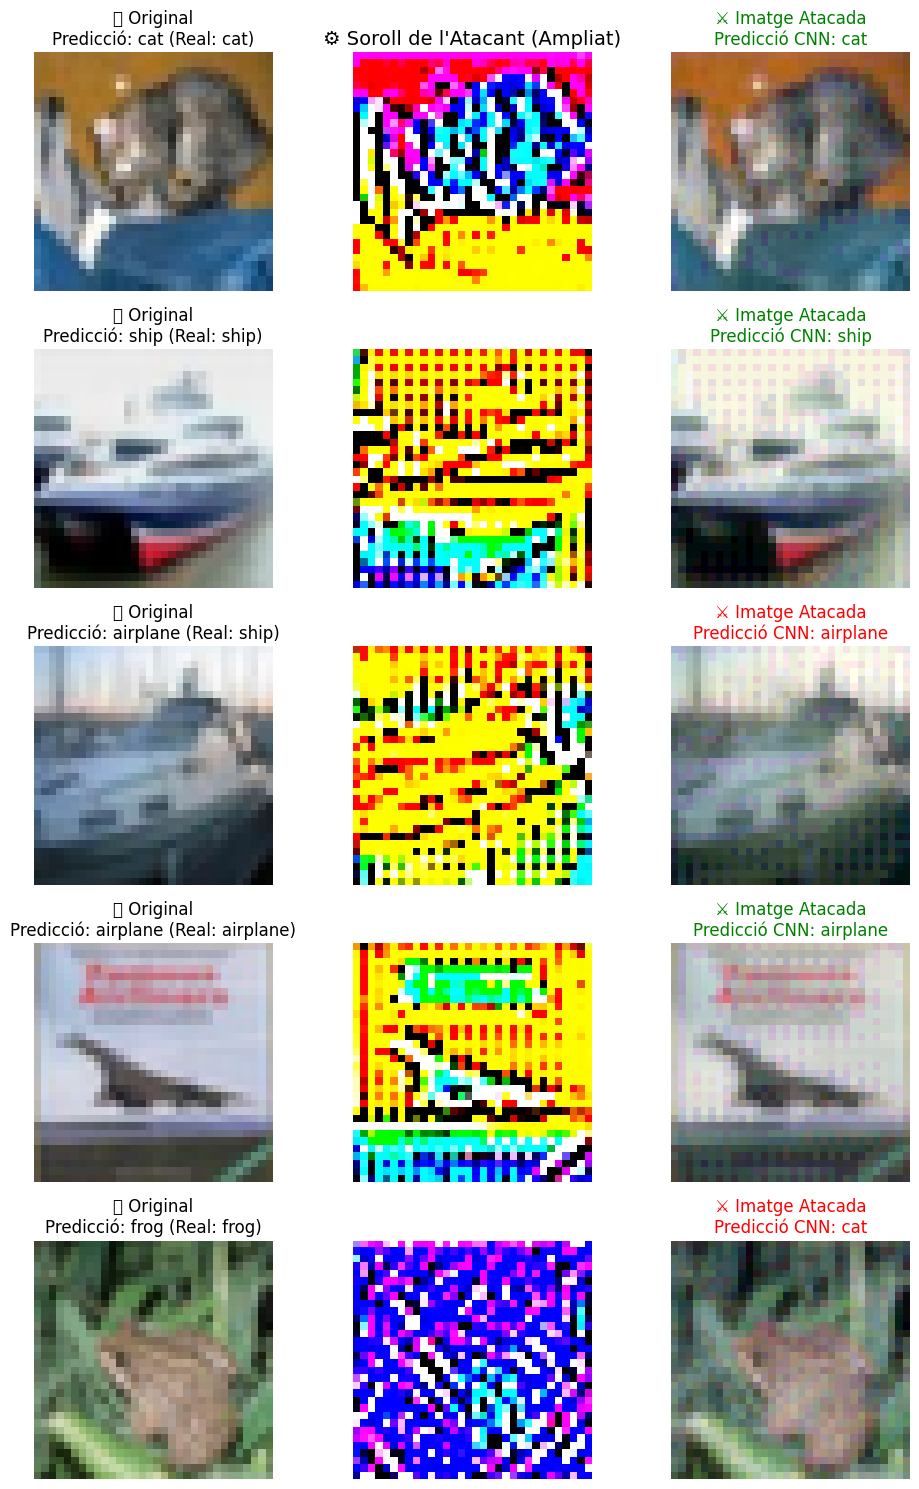

In [9]:
# List of classes to display names instead of numbers
classes = ('airplane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Function to denormalize images and prepare them for Matplotlib
def format_img(tensor):
    img = tensor.cpu().numpy()
    img = img / 2 + 0.5                 # 1. De-normalize from [-1, 1] to [0, 1]
    img = np.transpose(img, (1, 2, 0))  # 2. PyTorch (C, H, W) -> Matplotlib (H, W, C)
    return np.clip(img, 0, 1)           # 3. Ensure no pixel goes outside [0, 1]

# Function to make the noise (which are very small negative values) visible
def format_noise(tensor):
    noise = tensor.cpu().numpy()
    noise = np.transpose(noise, (1, 2, 0))
    # Scale the noise so we can see it well (from [min, max] to [0, 1])
    n_min, n_max = noise.min(), noise.max()
    if n_max - n_min > 1e-6:
        noise = (noise - n_min) / (n_max - n_min)
    return np.clip(noise, 0, 1)

# Define how many images from the batch we want to visualize
num_images = 5

# Take a single batch for visualization
images, labels = next(iter(testloader))
images, labels = images.to(device), labels.to(device)

# Attack generation and predictions
with torch.no_grad():
    x_adv, noise = generator(images, epsilon=epsilon)
    
    outputs_clean = classifier(images)
    _, pred_clean = torch.max(outputs_clean, 1)
    
    outputs_adv = classifier(x_adv)
    _, pred_adv = torch.max(outputs_adv, 1)

# Creation of the graphic
fig, axes = plt.subplots(num_images, 3, figsize=(10, 3 * num_images))

for idx in range(num_images):
    # Process  the tensors to images RGB using our functions
    img_clean = format_img(images[idx])
    img_noise = format_noise(noise[idx])
    img_adv = format_img(x_adv[idx])

    # Traanslate the class indices to class names
    label_true = classes[labels[idx].item()]
    label_clean = classes[pred_clean[idx].item()]
    label_adv = classes[pred_adv[idx].item()]

    # Column 0: Original Image
    axes[idx, 0].imshow(img_clean) # Ja no cal cmap='gray' perquè ara és RGB
    axes[idx, 0].set_title(f"🛡️ Original\nPredicció: {label_clean} (Real: {label_true})", fontsize=12)
    axes[idx, 0].axis('off')

    # Column 1: Attacker's Noise
    axes[idx, 1].imshow(img_noise)
    if idx == 0:
        axes[idx, 1].set_title("⚙️ Soroll de l'Atacant (Ampliat)", fontsize=14)
    axes[idx, 1].axis('off')

    # Column 2: Adversarial Image
    axes[idx, 2].imshow(img_adv)
    color = 'green' if label_adv == label_true else 'red'
    axes[idx, 2].set_title(f"⚔️ Imatge Atacada\nPredicció CNN: {label_adv}", fontsize=12, color=color)
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()